# Capstone Two: Exploratory Data Analysis
## Medical Cost Dataset

This notebook covers the exploratory data analysis (EDA) for my capstone project.  
The dataset contains information about patients — things like age, BMI, smoking status, health conditions, and lifestyle habits — and the goal is to understand what drives annual medical costs.

I'll be working through three main areas:
1. **Data profiles and inferential statistics**
2. **Data visualization**
3. **Feature selection and engineering**

## 1. Imports and Loading the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# just so plots look a bit nicer
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [5]:
df = pd.read_csv('medical_cost_cleaned.csv')
df.head()

,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,annual_medical_cost
0,69,Male,29.4,No,1,0,0,0,Medium,14825,4.4,8,1,0,4,Private,80.0,Semi-Urban,10885,2645.50
1,32,Female,22.9,No,1,0,0,0,Medium,3620,6.0,7,4,3,0,Government,64.0,Semi-Urban,18722,10959.70
2,89,Male,25.7,No,0,0,0,0,High,10578,4.5,7,2,0,3,NaN,NaN,Urban,4196,8409.80
3,78,Male,31.9,Yes,0,1,0,0,Low,6226,8.6,9,6,1,7,Government,70.0,Urban,11128,7996.62
4,38,Male,27.7,No,0,0,0,0,High,6253,5.7,3,6,0,6,Private,77.0,Urban,15110,3202.52


In [6]:
df.shape

(5000, 20)

So we have **5000 rows and 20 columns**. That's a good size to work with.  
Let me get a quick overview of all the columns and their types.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   gender                   5000 non-null   object 
 2   bmi                      5000 non-null   float64
 3   smoker                   5000 non-null   object 
 4   diabetes                 5000 non-null   int64  
 5   hypertension             5000 non-null   int64  
 6   heart_disease            5000 non-null   int64  
 7   asthma                   5000 non-null   int64  
 8   physical_activity_level  5000 non-null   object 
 9   daily_steps              5000 non-null   int64  
 10  sleep_hours              5000 non-null   float64
 11  stress_level             5000 non-null   int64  
 12  doctor_visits_per_year   5000 non-null   int64  
 13  hospital_admissions      5000 non-null   int64  
 14  medication_count        

In [8]:
df.describe()

,age,bmi,diabetes,hypertension,heart_disease,asthma,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_coverage_pct,previous_year_cost,annual_medical_cost
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,3952.000000,5000.000000,5000.000000
mean,53.299000,25.970820,0.207600,0.288000,0.14220,0.096400,7993.216800,6.488140,5.475400,4.030600,1.001000,3.509000,73.321103,10248.515400,8048.886894
std,20.646851,5.046651,0.405629,0.452876,0.34929,0.295169,4052.127069,1.443361,2.892312,2.010689,0.978566,2.292721,11.770946,5626.095015,7071.020228
min,18.000000,6.400000,0.000000,0.000000,0.00000,0.000000,1004.000000,4.000000,1.000000,0.000000,0.000000,0.000000,50.000000,500.000000,404.950000
25%,36.000000,22.600000,0.000000,0.000000,0.00000,0.000000,4545.000000,5.200000,3.000000,3.000000,0.000000,1.000000,65.000000,5342.750000,3241.977500
50%,53.000000,25.900000,0.000000,0.000000,0.00000,0.000000,7989.000000,6.500000,5.000000,4.000000,1.000000,3.000000,74.000000,10281.000000,5539.780000
75%,71.000000,29.400000,0.000000,1.000000,0.00000,0.000000,11532.250000,7.700000,8.000000,5.000000,2.000000,6.000000,82.000000,15034.500000,10094.097500
max,89.000000,43.600000,1.000000,1.000000,1.00000,1.000000,14999.000000,9.000000,10.000000,14.000000,6.000000,7.000000,94.000000,19996.000000,44792.100000


## 2. Checking for Missing Values

Even though the data was already cleaned, I want to double-check if there are still any nulls.

In [9]:
missing = df.isnull().sum()
missing[missing > 0]

insurance_type            1048
insurance_coverage_pct    1048
dtype: int64

Looks like `insurance_type` and `insurance_coverage_pct` both have **1048 missing values** — that's about 21% of the dataset.  
Since they were missing together (same rows), these patients probably just don't have insurance info recorded.

For now I'll leave them in place and work around them in visualizations. Later in feature engineering I'll handle this properly.

## 3. Data Profiles

### 3.1 Target Variable: Annual Medical Cost

Let me start by understanding what I'm trying to explain — the `annual_medical_cost` column.

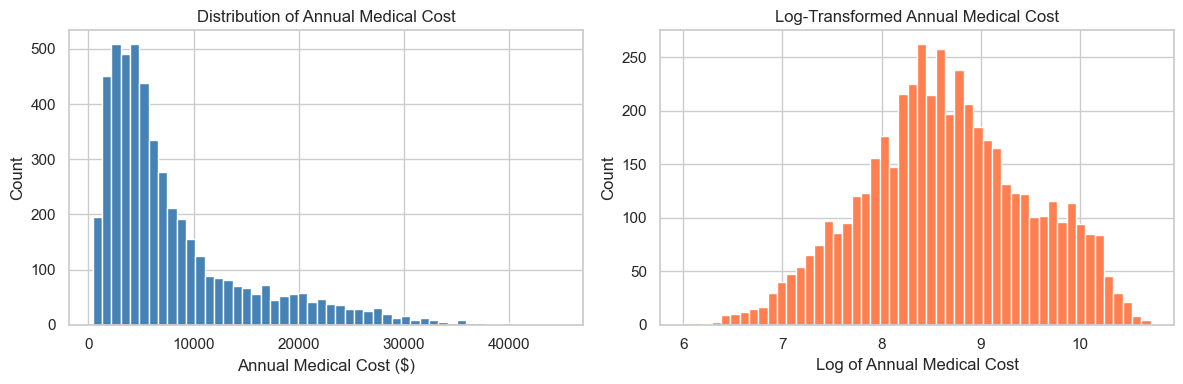

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['annual_medical_cost'], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Annual Medical Cost ($)')
plt.ylabel('Count')
plt.title('Distribution of Annual Medical Cost')

plt.subplot(1, 2, 2)
plt.hist(np.log(df['annual_medical_cost']), bins=50, color='coral', edgecolor='white')
plt.xlabel('Log of Annual Medical Cost')
plt.ylabel('Count')
plt.title('Log-Transformed Annual Medical Cost')

plt.tight_layout()
plt.show()

The cost distribution is **heavily right-skewed** — most people have relatively low costs but a small group has very high costs.  
The log-transformed version looks much more normal. This is pretty typical for cost/income data.  
I'll keep the original for now but might use the log version later for modelling.

In [11]:
# Summary stats for the target
df['annual_medical_cost'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
annual_medical_cost,5000.0,8048.886894,7071.020228,404.95,3241.9775,5539.78,10094.0975,44792.1


### 3.2 Categorical Features — Value Counts

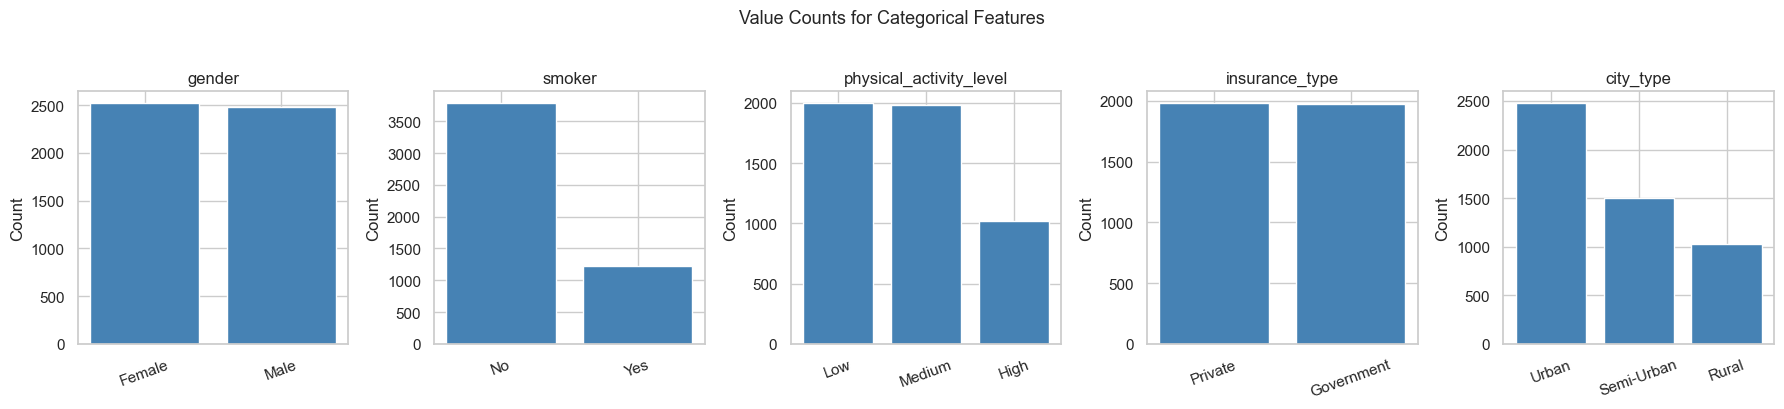

In [12]:
cat_cols = ['gender', 'smoker', 'physical_activity_level', 'insurance_type', 'city_type']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Value Counts for Categorical Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

A few things I notice:
- **Gender** is pretty evenly split between Male and Female — good, no major imbalance.
- **Smoker**: about 75% non-smokers, 25% smokers. Interesting that there are still quite a few smokers in the dataset.
- **Physical activity**: Low and Medium are roughly equal, High is about half of those — makes sense, not everyone is very active.
- **Insurance type**: Pretty even split between Private and Government among those who have insurance.
- **City type**: Mostly Urban, then Semi-Urban, then Rural.

### 3.3 Numeric Feature Distributions

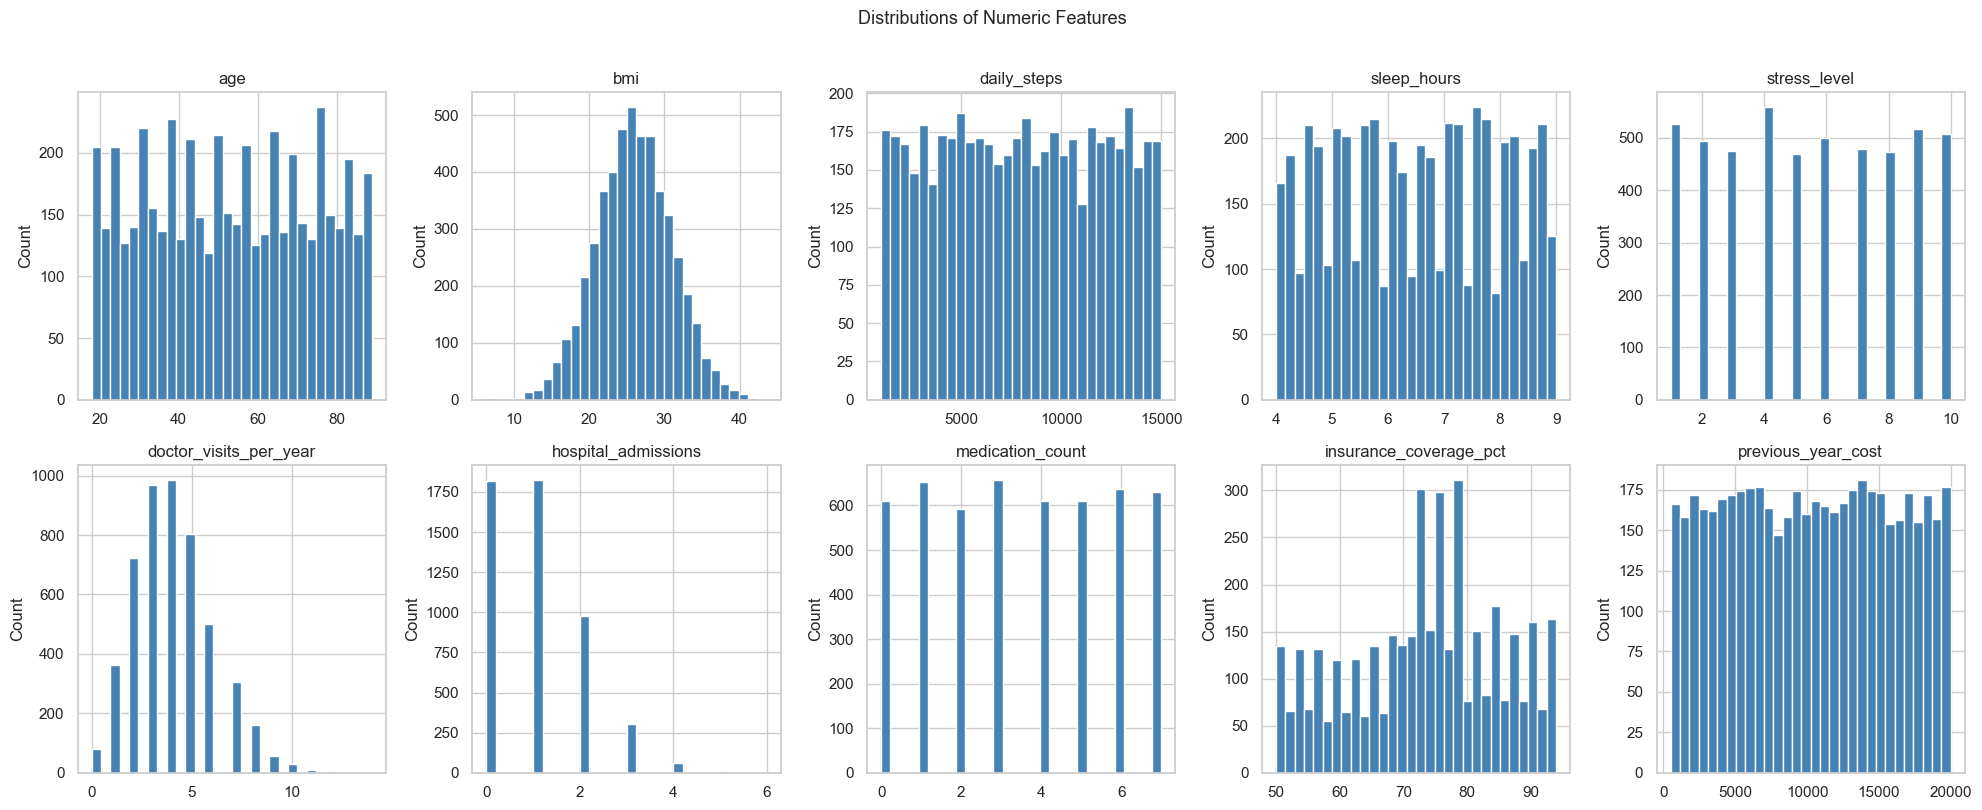

In [13]:
num_cols = ['age', 'bmi', 'daily_steps', 'sleep_hours', 'stress_level',
            'doctor_visits_per_year', 'hospital_admissions', 'medication_count',
            'insurance_coverage_pct', 'previous_year_cost']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Count')

plt.suptitle('Distributions of Numeric Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Some observations:
- **Age** is spread fairly uniformly from 18 to 89 — the dataset covers all adult age groups.
- **BMI** looks roughly normal, centered around 26. A few extreme values on both ends.
- **Daily steps** has a wide spread — some people are very sedentary, others very active.
- **Sleep hours** looks fairly uniform between about 4 and 10 hours.
- **Hospital admissions** is skewed right — most people have 0 or 1, but a few have many.
- **Insurance coverage %** shows a bimodal distribution — this might relate to the two insurance types.

### 3.4 Binary Health Condition Prevalence

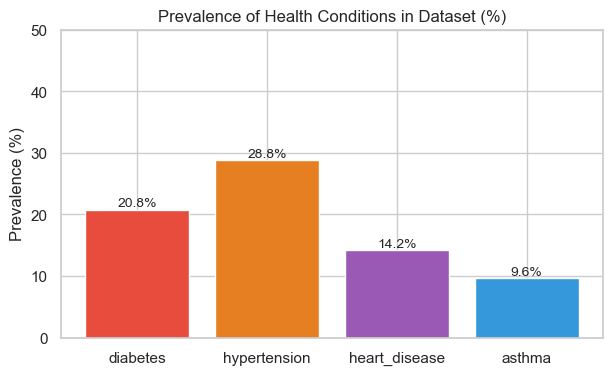

In [14]:
conditions = ['diabetes', 'hypertension', 'heart_disease', 'asthma']
prevalence = df[conditions].mean() * 100

plt.figure(figsize=(7, 4))
plt.bar(prevalence.index, prevalence.values, color=['#e74c3c', '#e67e22', '#9b59b6', '#3498db'], edgecolor='white')
plt.ylabel('Prevalence (%)')
plt.title('Prevalence of Health Conditions in Dataset (%)')
plt.ylim(0, 50)
for i, v in enumerate(prevalence.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)
plt.show()

Interesting — diabetes, hypertension, heart disease and asthma all have some presence in the data.  
Hypertension looks like the most common condition. I'd expect all of these to push up medical costs.

## 4. Inferential Statistics

Now I want to start forming some hypotheses about what drives medical costs and test them statistically.

### 4.1 Do smokers have significantly higher medical costs?

**Null Hypothesis (H₀):** There is no difference in average annual medical cost between smokers and non-smokers.  
**Alternative Hypothesis (H₁):** Smokers have higher average annual medical costs than non-smokers.

In [18]:
smokers     = df[df['smoker'] == 'Yes']['annual_medical_cost']
non_smokers = df[df['smoker'] == 'No']['annual_medical_cost']

t_stat, p_val = stats.ttest_ind(smokers, non_smokers, alternative='greater')

pd.DataFrame({
    'Group':         ['Smokers', 'Non-Smokers'],
    'Mean Cost ($)': [round(smokers.mean(), 2), round(non_smokers.mean(), 2)],
    'Std Dev':       [round(smokers.std(), 2), round(non_smokers.std(), 2)],
    'N':             [len(smokers), len(non_smokers)]
})

,Group,Mean Cost ($),Std Dev,N
0,Smokers,8816.01,7600.64,1221
1,Non-Smokers,7801.03,6873.98,3779


In [19]:
pd.DataFrame({
    'Test':    ['Independent t-test (one-tailed)'],
    't-stat':  [round(t_stat, 4)],
    'p-value': [round(p_val, 6)]
})

,Test,t-stat,p-value
0,Independent t-test (one-tailed),4.3684,0.000006


The p-value is below 0.05, so we **reject the null hypothesis**.  
Smokers do have significantly higher medical costs on average. This makes sense — smoking is associated with a huge range of health problems.

### 4.2 Does having heart disease significantly increase costs?

**H₀:** Mean annual cost is the same for patients with and without heart disease.  
**H₁:** Patients with heart disease have higher costs.

In [20]:
heart_yes = df[df['heart_disease'] == 1]['annual_medical_cost']
heart_no  = df[df['heart_disease'] == 0]['annual_medical_cost']

t2, p2 = stats.ttest_ind(heart_yes, heart_no, alternative='greater')

pd.DataFrame({
    'Group':         ['Heart Disease', 'No Heart Disease'],
    'Mean Cost ($)': [heart_yes.mean().round(2), heart_no.mean().round(2)],
    'N':             [len(heart_yes), len(heart_no)],
    'p-value':       [round(p2, 6), '']
})

,Group,Mean Cost ($),N,p-value
0,Heart Disease,10162.93,711,0.0
1,No Heart Disease,7698.44,4289,


Again significant! Patients with heart disease have noticeably higher average annual costs.  
The sample size for heart disease is smaller though, so it's good that the result is still clear.

### 4.3 Is there a difference in costs across city types?

**H₀:** Mean annual medical cost is the same across Urban, Semi-Urban, and Rural areas.  
**H₁:** At least one city type has a different mean cost.

For this one I'll use a one-way ANOVA since there are three groups.

In [21]:
urban      = df[df['city_type'] == 'Urban']['annual_medical_cost']
semi_urban = df[df['city_type'] == 'Semi-Urban']['annual_medical_cost']
rural      = df[df['city_type'] == 'Rural']['annual_medical_cost']

f_stat, p_anova = stats.f_oneway(urban, semi_urban, rural)

pd.DataFrame({
    'City Type':     ['Urban', 'Semi-Urban', 'Rural'],
    'Mean Cost ($)': [urban.mean().round(2), semi_urban.mean().round(2), rural.mean().round(2)],
    'N':             [len(urban), len(semi_urban), len(rural)],
}).set_index('City Type')

,Mean Cost ($),N
City Type,,
Urban,8009.36,2474
Semi-Urban,7974.27,1503
Rural,8254.10,1023


In [22]:
pd.DataFrame({'F-statistic': [round(f_stat, 4)], 'p-value': [round(p_anova, 4)]})

,F-statistic,p-value
0,0.5531,0.5752


The ANOVA p-value is above 0.05, so we **fail to reject the null hypothesis**.  
There is no statistically significant difference in medical costs between city types.  
This surprised me a little — I expected urban areas to have higher costs, but the data doesn't support that.

### 4.4 Correlation between insurance coverage % and cost

**H₀:** There is no linear correlation between insurance coverage percentage and annual medical cost.  
**H₁:** There is a significant negative correlation (more coverage = lower out-of-pocket cost).

In [23]:
df_ins = df[['insurance_coverage_pct', 'annual_medical_cost']].dropna()

r, p_corr = stats.pearsonr(df_ins['insurance_coverage_pct'], df_ins['annual_medical_cost'])

pd.DataFrame({
    'Pearson r': [round(r, 4)],
    'p-value':   [round(p_corr, 6)],
    'N':         [len(df_ins)]
})

,Pearson r,p-value,N
0,-0.7388,0.0,3952


Wow — the correlation is **-0.74**, which is actually a really strong negative relationship.  
Patients with higher insurance coverage have significantly lower annual costs.  
This makes perfect sense: better coverage means the insurance pays more, so out-of-pocket costs are lower.  
This is probably going to be one of the most important features in any model.

## 5. Data Visualization

### 5.1 Annual Cost by Smoker Status

/var/folders/kq/wf2fxs3j0j1_z43cz83vpkp00000gp/T/ipykernel_30402/729064848.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='annual_medical_cost', palette=['steelblue', 'coral'])


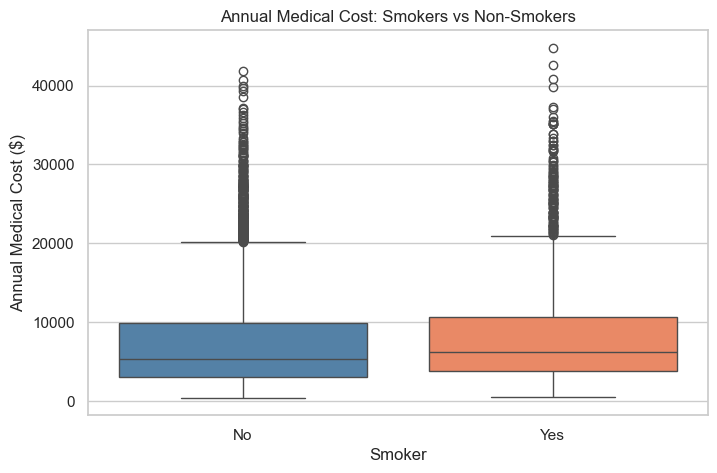

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='smoker', y='annual_medical_cost', palette=['steelblue', 'coral'])
plt.xlabel('Smoker')
plt.ylabel('Annual Medical Cost ($)')
plt.title('Annual Medical Cost: Smokers vs Non-Smokers')
plt.show()

Smokers clearly have a higher median cost AND more high-cost outliers.  
The boxes don't overlap much — this confirms the t-test result visually.

### 5.2 Annual Cost vs Insurance Coverage %

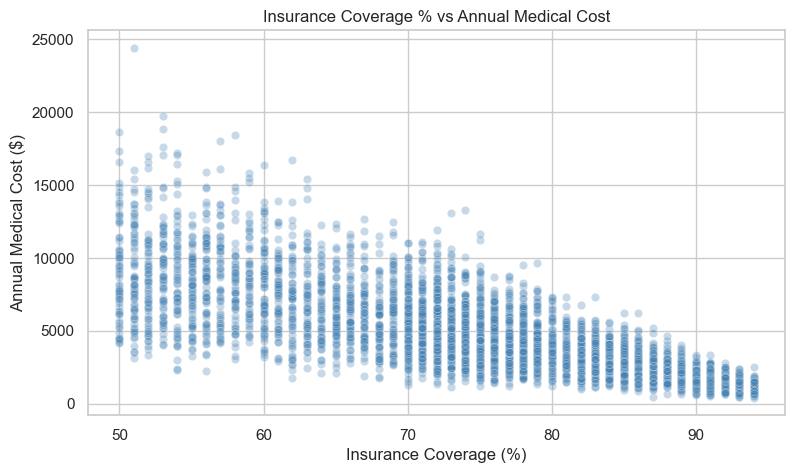

In [25]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df.dropna(subset=['insurance_coverage_pct']),
                x='insurance_coverage_pct', y='annual_medical_cost',
                alpha=0.3, color='steelblue')
plt.xlabel('Insurance Coverage (%)')
plt.ylabel('Annual Medical Cost ($)')
plt.title('Insurance Coverage % vs Annual Medical Cost')
plt.show()

You can clearly see the strong downward trend here. As coverage goes up, cost comes down.  
There is a lot of scatter though — even at 90% coverage, some people still have high costs. Interesting.

### 5.3 Cost by Physical Activity Level

/var/folders/kq/wf2fxs3j0j1_z43cz83vpkp00000gp/T/ipykernel_30402/3345429689.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='physical_activity_level', y='annual_medical_cost',


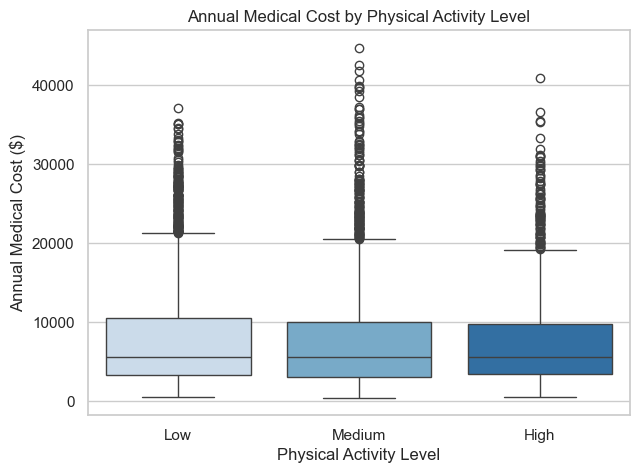

In [26]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='physical_activity_level', y='annual_medical_cost',
            order=['Low', 'Medium', 'High'], palette='Blues')
plt.xlabel('Physical Activity Level')
plt.ylabel('Annual Medical Cost ($)')
plt.title('Annual Medical Cost by Physical Activity Level')
plt.show()

There's a slight trend here — High activity has a lower median cost than Low.  
But the difference isn't huge and there's a lot of overlap. Physical activity alone probably isn't a strong predictor.

### 5.4 Cost by Number of Hospital Admissions

/var/folders/kq/wf2fxs3j0j1_z43cz83vpkp00000gp/T/ipykernel_30402/1605212392.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='hospital_admissions', y='annual_medical_cost', palette='flare')


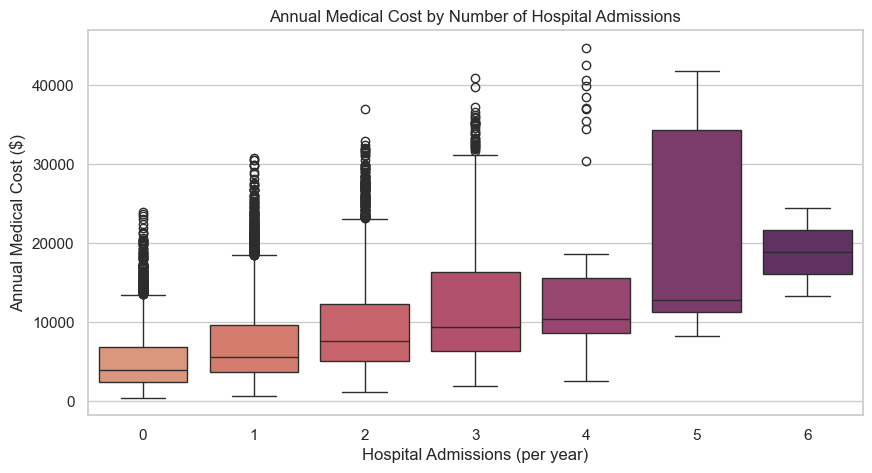

In [27]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='hospital_admissions', y='annual_medical_cost', palette='flare')
plt.xlabel('Hospital Admissions (per year)')
plt.ylabel('Annual Medical Cost ($)')
plt.title('Annual Medical Cost by Number of Hospital Admissions')
plt.show()

This is a very clear pattern — more hospital admissions = much higher costs.  
The median cost jumps substantially with each additional admission. This makes total sense and matches the correlation we saw earlier.

### 5.5 Age vs Annual Cost

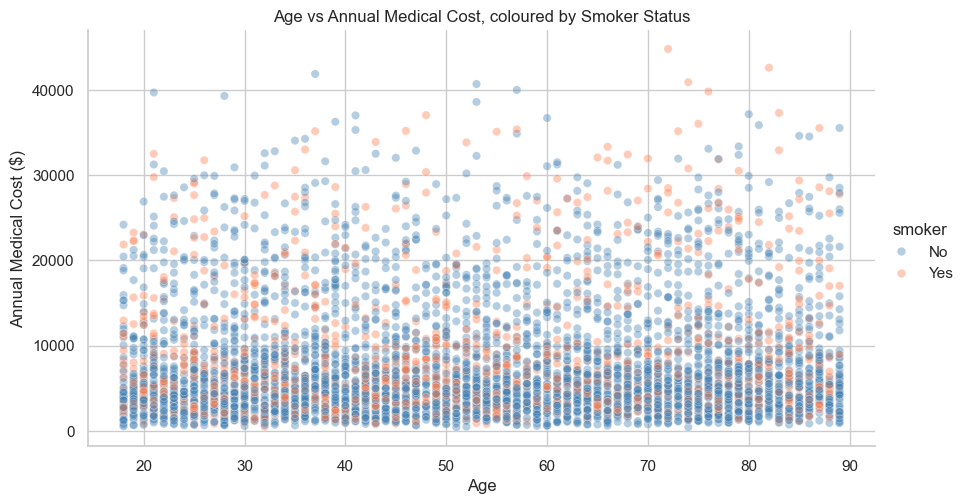

In [28]:
sns.relplot(data=df, x='age', y='annual_medical_cost',
            hue='smoker', alpha=0.4, height=5, aspect=1.8,
            palette={'No': 'steelblue', 'Yes': 'coral'})
plt.xlabel('Age')
plt.ylabel('Annual Medical Cost ($)')
plt.title('Age vs Annual Medical Cost, coloured by Smoker Status')
plt.show()

Interesting — age doesn't seem to have a super strong linear relationship with cost on its own.  
But when you split by smoker status, the smokers (coral) do seem to be scattered higher.  
I expected age to be a bigger driver here — maybe it's being masked by other factors like hospital admissions.

### 5.6 BMI vs Annual Cost

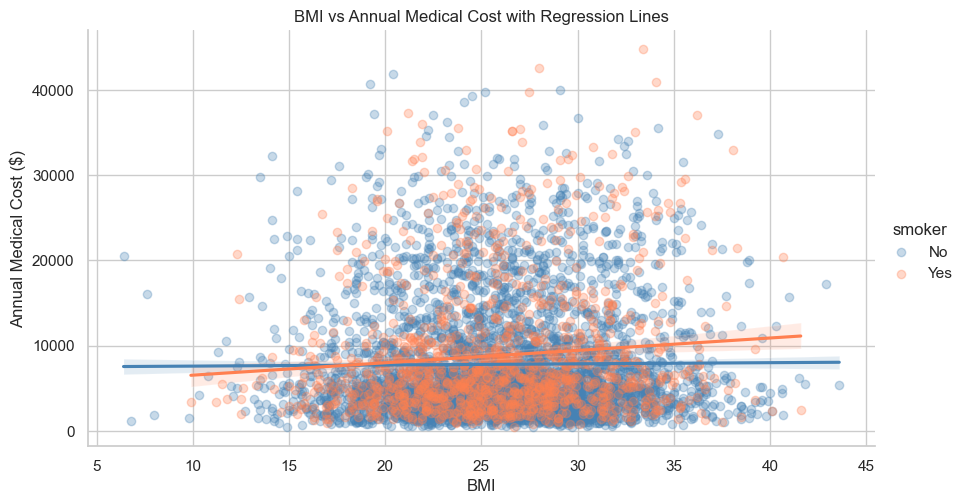

In [29]:
sns.lmplot(data=df, x='bmi', y='annual_medical_cost',
           hue='smoker', palette={'No': 'steelblue', 'Yes': 'coral'},
           scatter_kws={'alpha': 0.3}, height=5, aspect=1.8)
plt.xlabel('BMI')
plt.ylabel('Annual Medical Cost ($)')
plt.title('BMI vs Annual Medical Cost with Regression Lines')
plt.show()

The regression lines are both fairly flat — BMI doesn't seem to be a strong predictor of cost either.  
Smokers still skew higher overall. Maybe the relationship between BMI and cost only shows up when combined with conditions like diabetes or heart disease.

### 5.7 Cost by Insurance Type

/var/folders/kq/wf2fxs3j0j1_z43cz83vpkp00000gp/T/ipykernel_30402/3218449569.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df.dropna(subset=['insurance_type']),


<Figure size 700x500 with 0 Axes>

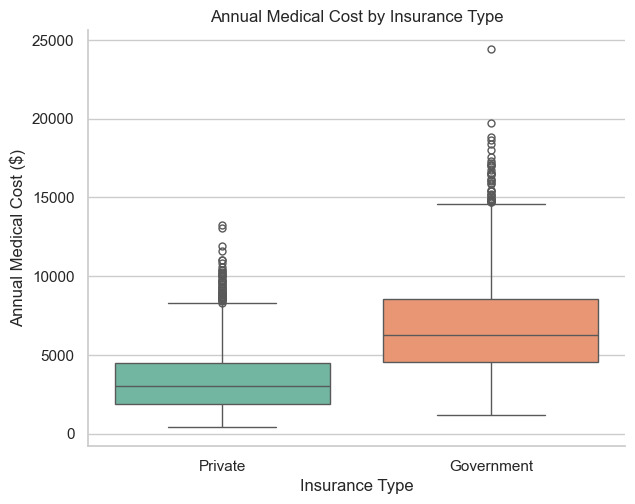

In [30]:
plt.figure(figsize=(7, 5))
sns.catplot(data=df.dropna(subset=['insurance_type']),
            x='insurance_type', y='annual_medical_cost',
            kind='box', palette='Set2', height=5, aspect=1.3)
plt.xlabel('Insurance Type')
plt.ylabel('Annual Medical Cost ($)')
plt.title('Annual Medical Cost by Insurance Type')
plt.show()

Government insurance holders have notably higher costs than Private insurance holders.  
This might seem counterintuitive but could reflect that people with Government insurance tend to be older or have more health conditions. Worth investigating further.

### 5.8 Correlation Heatmap

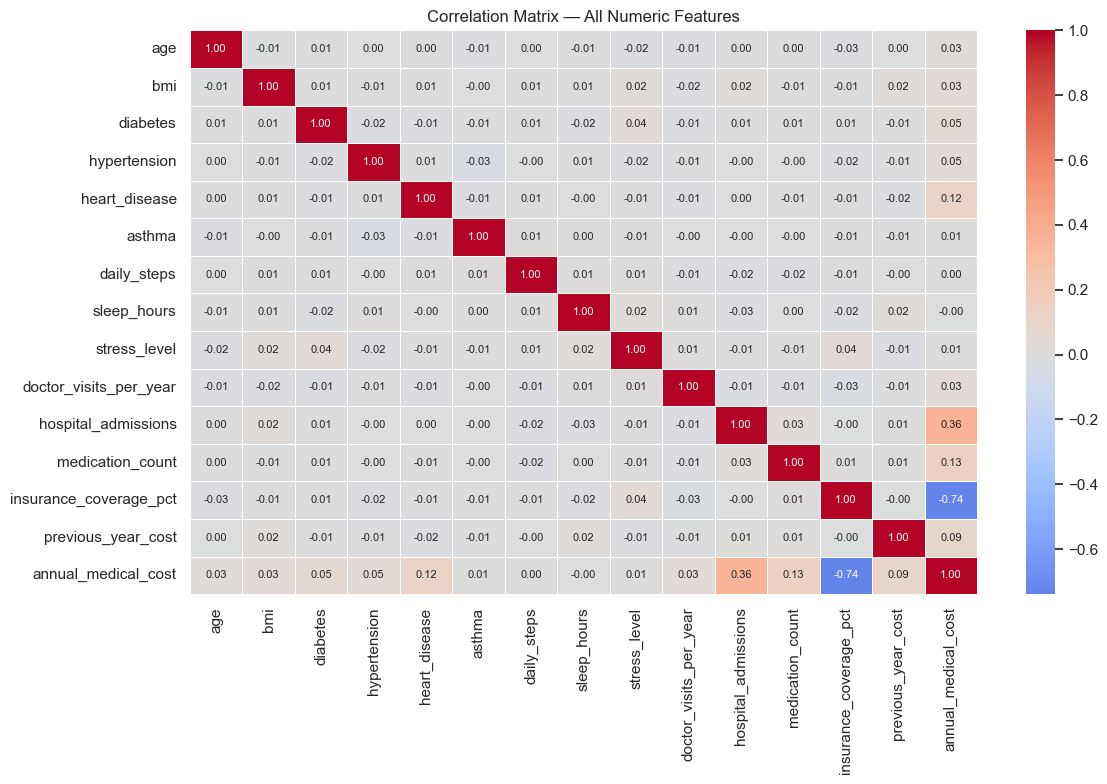

In [31]:
plt.figure(figsize=(12, 8))
corr_matrix = df.select_dtypes(include='number').corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix — All Numeric Features')
plt.tight_layout()
plt.show()

Key things I notice from the heatmap:
- **insurance_coverage_pct** has the strongest correlation with cost (strongly negative, -0.74)
- **hospital_admissions** is the next strongest positive predictor (0.36)
- **medication_count** and **heart_disease** also correlate with cost to some degree
- Most other features have very weak correlations with cost — less than 0.1
- **previous_year_cost** correlates moderately with this year's cost (0.09) — not as strong as I expected

The low correlations for age and BMI are surprising given what we know from medical literature.

### 5.9 Pairplot of Key Variables

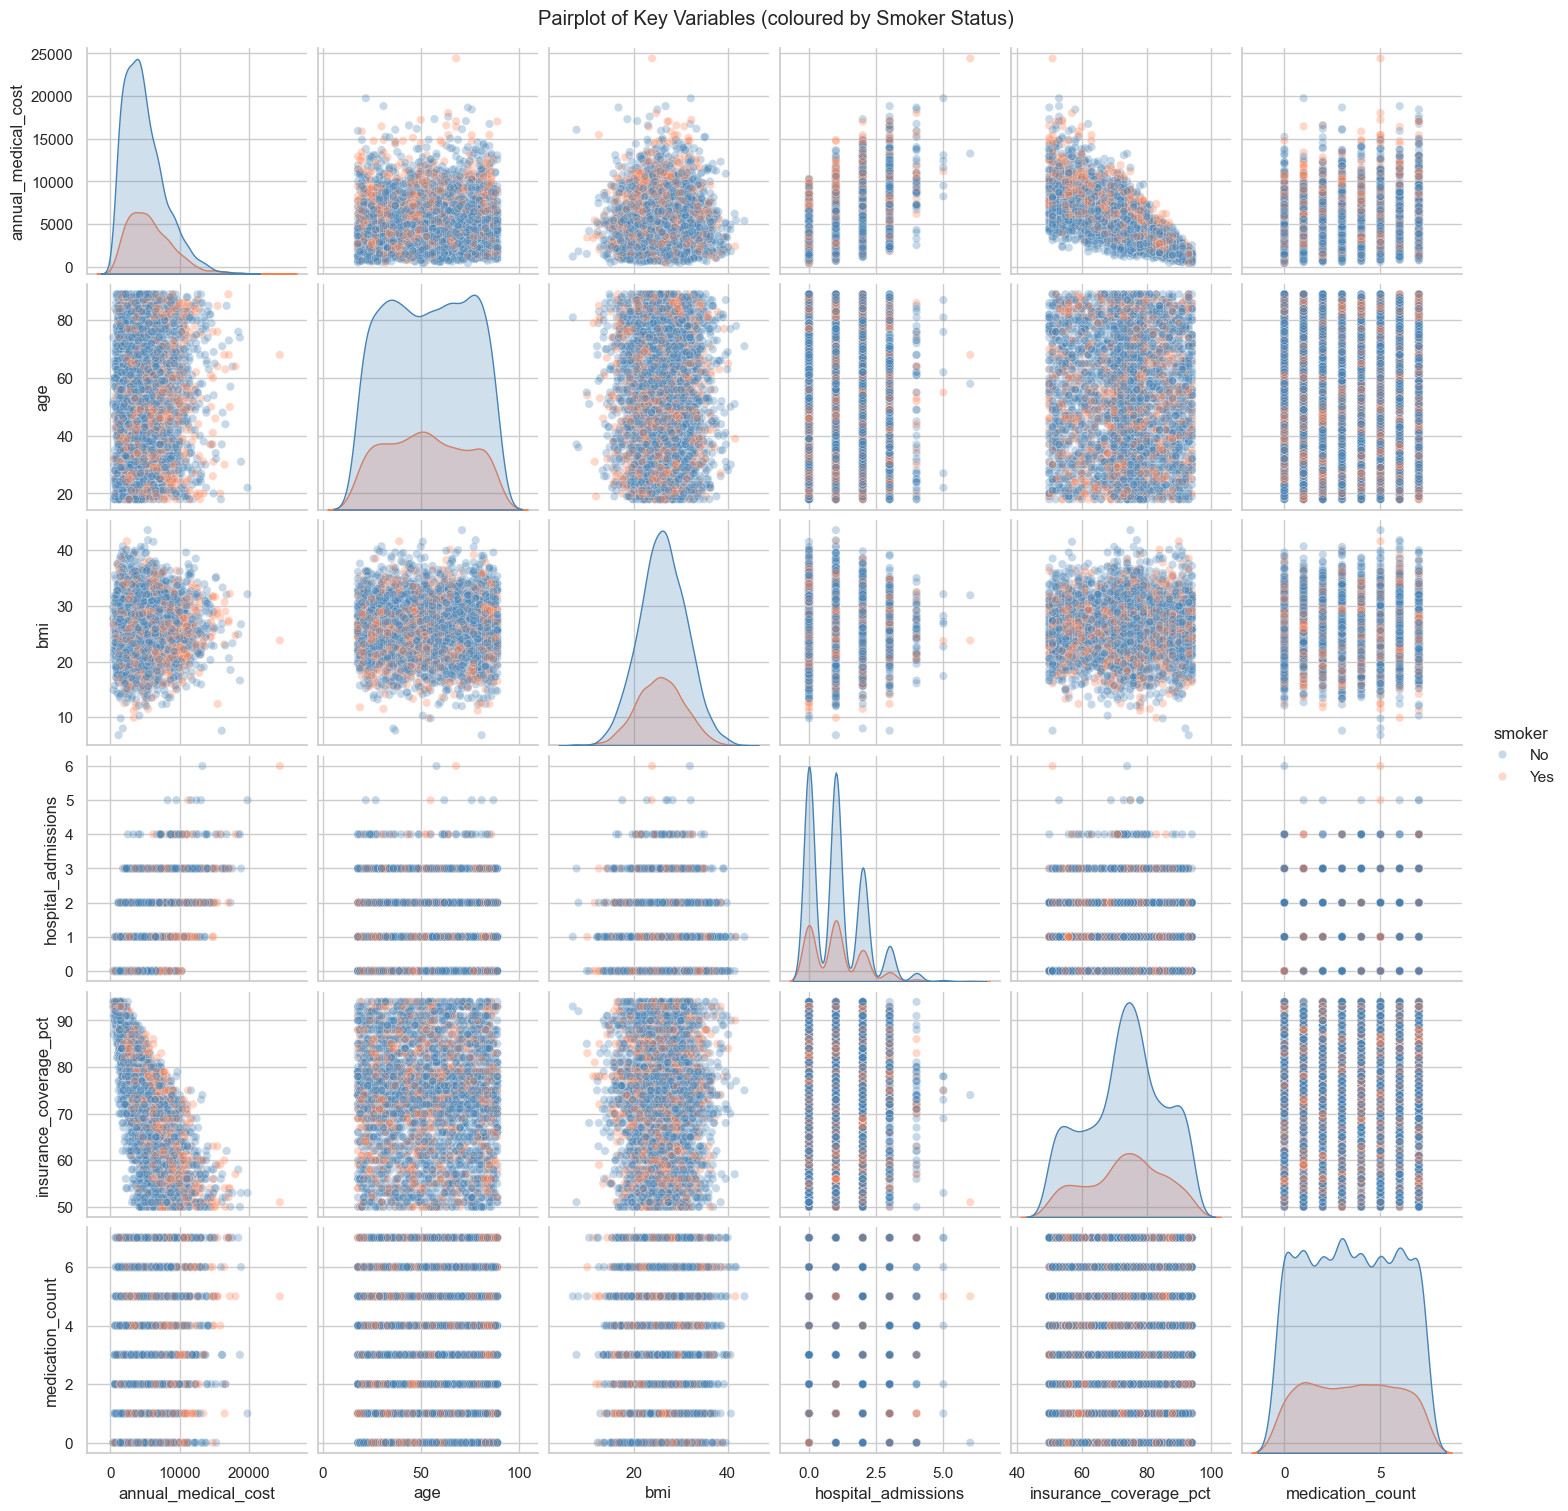

In [32]:
key_vars = ['annual_medical_cost', 'age', 'bmi', 'hospital_admissions',
             'insurance_coverage_pct', 'medication_count']

sns.pairplot(df[key_vars + ['smoker']].dropna(),
             hue='smoker', plot_kws={'alpha': 0.3},
             palette={'No': 'steelblue', 'Yes': 'coral'})
plt.suptitle('Pairplot of Key Variables (coloured by Smoker Status)', y=1.01)
plt.show()

The pairplot shows that most variables don't have super clean linear relationships with each other.  
The `insurance_coverage_pct` vs `annual_medical_cost` relationship is the clearest one — strong negative linear trend.  
Smokers (coral) tend to sit slightly higher on the cost axis across most plots.

## 6. Feature Selection and Engineering

### 6.1 Handling Missing Values in Insurance Columns

About 21% of rows are missing `insurance_type` and `insurance_coverage_pct`.  
Since these go together, I'll assume these patients have no insurance and fill accordingly.

In [33]:
df['insurance_type'] = df['insurance_type'].fillna('None')
df['insurance_coverage_pct'] = df['insurance_coverage_pct'].fillna(0)

print('Missing values remaining:')
df[['insurance_type', 'insurance_coverage_pct']].isnull().sum().to_frame('Missing')

Missing values remaining:


,Missing
insurance_type,0
insurance_coverage_pct,0


### 6.2 One-Hot Encoding Categorical Features

In [34]:
df_encoded = pd.get_dummies(df, columns=['gender', 'smoker', 'physical_activity_level',
                                            'insurance_type', 'city_type'],
                              drop_first=True)

print(f'Shape before encoding: {df.shape}')
print(f'Shape after encoding:  {df_encoded.shape}')
df_encoded.head(3)

Shape before encoding: (5000, 20)
Shape after encoding:  (5000, 23)


,age,bmi,diabetes,hypertension,heart_disease,asthma,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,...,previous_year_cost,annual_medical_cost,gender_Male,smoker_Yes,physical_activity_level_Low,physical_activity_level_Medium,insurance_type_None,insurance_type_Private,city_type_Semi-Urban,city_type_Urban
0,69,29.4,1,0,0,0,14825,4.4,8,1,...,10885,2645.5,True,False,False,True,False,True,True,False
1,32,22.9,1,0,0,0,3620,6.0,7,4,...,18722,10959.7,False,False,False,True,False,False,True,False
2,89,25.7,0,0,0,0,10578,4.5,7,2,...,4196,8409.8,True,False,False,False,True,False,False,True


One-hot encoding converts our categorical columns into binary (0/1) columns so they can be used in a model.  
I used `drop_first=True` to avoid the dummy variable trap — so for example `gender` now just has a `gender_Male` column (Female is the baseline).

### 6.3 Log Transforming the Target Variable

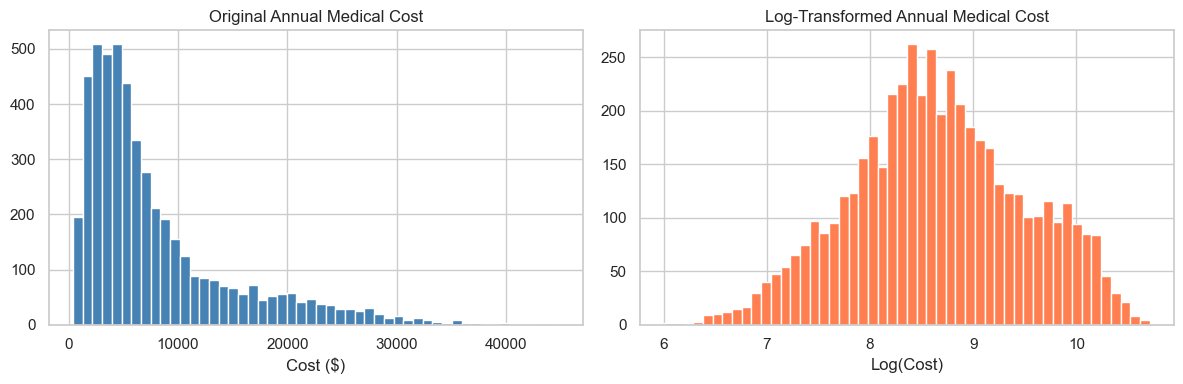

In [35]:
df_encoded['log_annual_medical_cost'] = np.log(df_encoded['annual_medical_cost'])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df_encoded['annual_medical_cost'], bins=50, color='steelblue', edgecolor='white')
plt.title('Original Annual Medical Cost')
plt.xlabel('Cost ($)')

plt.subplot(1, 2, 2)
plt.hist(df_encoded['log_annual_medical_cost'], bins=50, color='coral', edgecolor='white')
plt.title('Log-Transformed Annual Medical Cost')
plt.xlabel('Log(Cost)')

plt.tight_layout()
plt.show()

The log-transformed version looks much more normally distributed.  
This is important for linear regression which assumes the errors are normally distributed.  
I'll keep both versions — the original for interpretation and the log version for modelling.

### 6.4 Creating an Age Group Feature

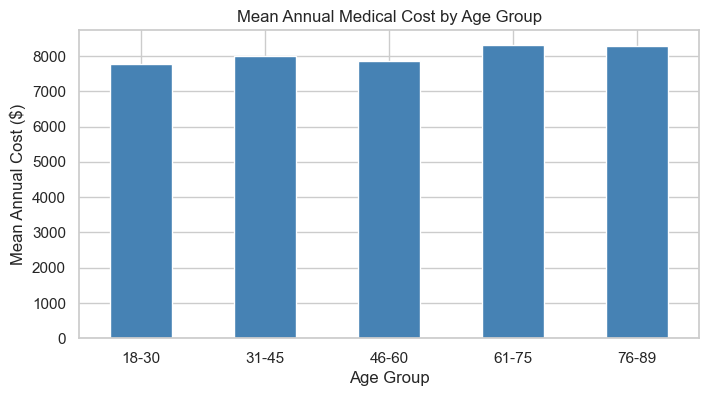

In [36]:
bins   = [17, 30, 45, 60, 75, 90]
labels = ['18-30', '31-45', '46-60', '61-75', '76-89']

df_encoded['age_group'] = pd.cut(df_encoded['age'], bins=bins, labels=labels)

plt.figure(figsize=(8, 4))
df_encoded.groupby('age_group', observed=True)['annual_medical_cost'].mean().plot(kind='bar',
    color='steelblue', edgecolor='white')
plt.ylabel('Mean Annual Cost ($)')
plt.xlabel('Age Group')
plt.title('Mean Annual Medical Cost by Age Group')
plt.xticks(rotation=0)
plt.show()

Binning age into groups makes the age-cost relationship a bit clearer.  
There is an upward trend — older age groups do tend to have higher average costs.  
The effect wasn't obvious in the scatter plot but the binned version reveals it more clearly.

### 6.5 Creating a 'Total Conditions' Feature

/var/folders/kq/wf2fxs3j0j1_z43cz83vpkp00000gp/T/ipykernel_30402/2482550612.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_encoded, x='total_conditions', y='annual_medical_cost', palette='Oranges')


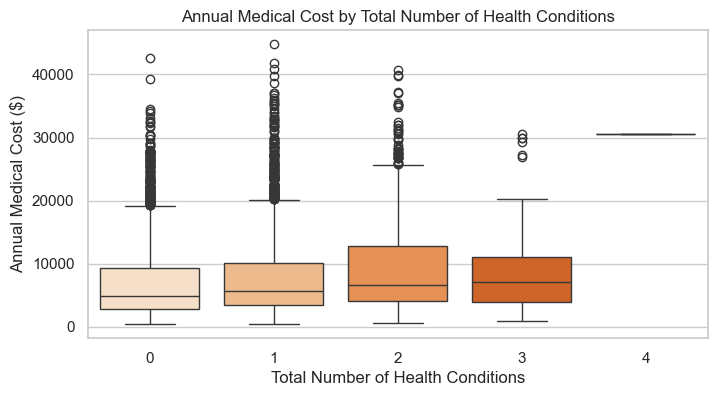

In [37]:
condition_cols = ['diabetes', 'hypertension', 'heart_disease', 'asthma']
df_encoded['total_conditions'] = df_encoded[condition_cols].sum(axis=1)

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_encoded, x='total_conditions', y='annual_medical_cost', palette='Oranges')
plt.xlabel('Total Number of Health Conditions')
plt.ylabel('Annual Medical Cost ($)')
plt.title('Annual Medical Cost by Total Number of Health Conditions')
plt.show()

There's a fairly clear upward trend here — the more health conditions a patient has, the higher their average cost.  
Combining the individual condition flags into a single count feature might be more useful than having 4 separate binary columns, especially since each individual condition had a weak correlation with cost.

### 6.6 Outlier Check on Medical Cost

In [38]:
Q1 = df_encoded['annual_medical_cost'].quantile(0.25)
Q3 = df_encoded['annual_medical_cost'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_encoded[(df_encoded['annual_medical_cost'] < lower) |
                       (df_encoded['annual_medical_cost'] > upper)]

pd.DataFrame({
    'Metric': ['Q1', 'Q3', 'IQR', 'Lower Bound', 'Upper Bound', 'Outlier Count', 'Outlier %'],
    'Value': [Q1, Q3, IQR, lower, upper, len(outliers), f'{len(outliers)/len(df_encoded)*100:.1f}%']
}).set_index('Metric')

,Value
Metric,
Q1,3241.9775
Q3,10094.0975
IQR,6852.12
Lower Bound,-7036.2025
Upper Bound,20372.2775
Outlier Count,416
Outlier %,8.3%


There are some outliers on the high end of cost. These are patients with extremely high medical expenses — likely due to serious conditions or many hospital admissions.  
I will **not** remove them for now because they represent real patients and removing them might bias the analysis. But I'll keep an eye on them when modelling.

## 7. Feature Selection Summary

Based on everything I've looked at, here's my thinking on which features are most likely to be useful for modelling annual medical costs:

| Feature | Reasoning |
|---|---|
| `insurance_coverage_pct` | Strongest correlation (-0.74). Very important. |
| `hospital_admissions` | Clear positive relationship with cost (0.36). Keep. |
| `smoker` | Statistically significant difference in costs. Keep. |
| `medication_count` | Moderate correlation. Keep. |
| `heart_disease` | Significant difference in costs. Keep. |
| `total_conditions` | Engineered feature — combines all 4 health conditions. |
| `age_group` | Binned age shows clearer trend than raw age. |
| `insurance_type` | Significant cost difference between types. Keep. |
| `previous_year_cost` | Reasonable to assume last year predicts this year. Keep. |
| `bmi` | Weak correlation alone but may interact with conditions. |
| `daily_steps` / `sleep_hours` | Very weak correlation. Probably drop. |
| `city_type` | ANOVA showed no significant difference. Probably drop. |

The clearest story from this EDA is that **insurance coverage is by far the biggest driver of out-of-pocket costs**, followed by **hospital admissions** and **whether the patient smokes**.

## 8. Summary 

### What I found:
- **Insurance coverage %** is the dominant predictor of annual medical cost (r = -0.74)
- **Hospital admissions** are the next most important predictor
- **Smokers** have significantly higher costs (t-test confirmed)
- **Heart disease** is associated with significantly higher costs
- **City type** does NOT significantly affect costs (ANOVA p > 0.05)
- **Age and BMI** have surprisingly weak direct correlations with cost — they may only matter in combination with health conditions

### Feature engineering done:
- Filled missing insurance data with `'None'` / `0` (assuming uninsured)
- One-hot encoded all categorical features
- Log-transformed the target variable for potential use in modelling
- Created `age_group` bins to capture non-linear age effect
- Created `total_conditions` by summing the 4 binary health condition flags



In [ ]:
# Save the dataset for the next stage
df.to_csv('medical_cost_cleaned.csv', index=False)
print('Cleaned dataset saved as medical_cost_cleaned.csv')